In [1]:
import numpy as np
from src.image_analyzer import ImageAnalyzer
from src.numbering import DynamicImageNumbering, Numbering
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from tqdm import tqdm

In [57]:
images_folder_path = r"Z:\victor\dynamic_imaging\Apr17_2026_154933images"
n_reps = 100
n_max = 11
numbering = DynamicImageNumbering(n_max=n_max, n_reps=n_reps)
analyzer_images = ImageAnalyzer(calibration_file="calibration20260309.json",
images_folder_path=images_folder_path,
numbering=numbering
)

analyzer_images.analyze_images()
analyzer_images.data.drop(columns=["atoms_in_image"]).to_parquet("images_data.parquet")
dqtq_images = analyzer_images.data
# data_images = pd.read_parquet("images_data.parquet")

images analyzed with data taken on:  2026-03-09
expecting an atom array of size:  10 x 10
the ROIs are of size:  5 x 5
images to analyze are in:  Z:\victor\dynamic_imaging\Apr17_2026_154933images
number of images on the disk: 7700
number of images to analyze: 7700


In [16]:
data_images.head()

,total_atoms,n,image_index,repetition_index
0,53,0,0,0
1,52,0,1,0
2,65,1,0,0
3,65,1,1,0
4,66,1,2,0


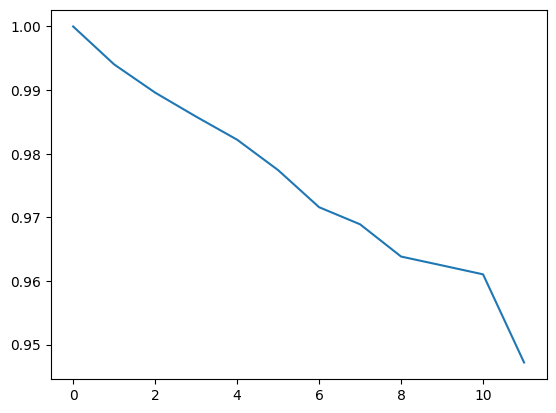

In [17]:
decrease_data = data_images.groupby("image_index")["total_atoms"].mean()

plt.plot(decrease_data / decrease_data.iloc[0])
plt.show()

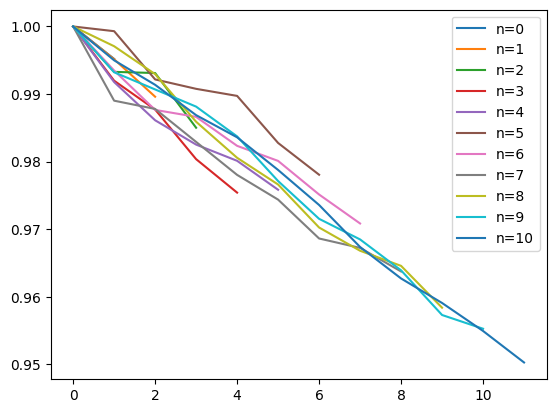

In [18]:
for n in range(n_max):
    data_n = data_images[data_images["n"] == n]
    mean_data = data_n.groupby("image_index")["total_atoms"].mean()
    plt.plot(mean_data / mean_data.iloc[0], label=f"n={n}")
plt.legend()
plt.show()


In [59]:
@dataclass
class IdleNumbering(Numbering):
    n_max: int  # maximum value for $n$
    n_reps: int  # number of repetitions for each value of $n$

    def indices(self) -> list[dict[str, int]]:
        for r in range(self.n_reps):
            for n in range(self.n_max):
                yield {"n": n, "image_index": 0, "repetition_index": r}
                # for image_i in range(n):
                #     yield {"n": n, "image_index": image_i+1, "repetition_index": r}
                yield {"n": n, "image_index": 1, "repetition_index": r}


In [60]:
idle_folder_path = r"Z:\victor\dynamic_imaging\Apr17_2026_171725idle"
n_reps = 100
n_max = 11
numbering = IdleNumbering(n_max=n_max, n_reps=n_reps)
analyzer_idle = ImageAnalyzer(calibration_file="calibration20260309.json",
images_folder_path=idle_folder_path,
numbering=numbering
)

# analyzer_idle.analyze_images()
# analyzer_idle.data.drop(columns=["atoms_in_image"]).to_parquet("idle_data.parquet")
# idle_data = analyzer_idle.data
data_idle = pd.read_parquet("idle_data.parquet")

images analyzed with data taken on:  2026-03-09
expecting an atom array of size:  10 x 10
the ROIs are of size:  5 x 5
images to analyze are in:  Z:\victor\dynamic_imaging\Apr17_2026_171725idle


In [61]:
def plot_n(n):
    data_idle_n = data_idle[data_idle["n"] == n]
    mean_idle = data_idle_n.groupby("image_index")["total_atoms"].mean()
    data_images_n = data_images[data_images["n"] == n]
    mean_images = data_images_n.groupby("image_index")["total_atoms"].mean()
    plt.plot([0, len(mean_images)], mean_idle / mean_idle.iloc[0], label=f"idle n={n}")
    plt.plot(mean_images / mean_images.iloc[0], label=f"images n={n}")

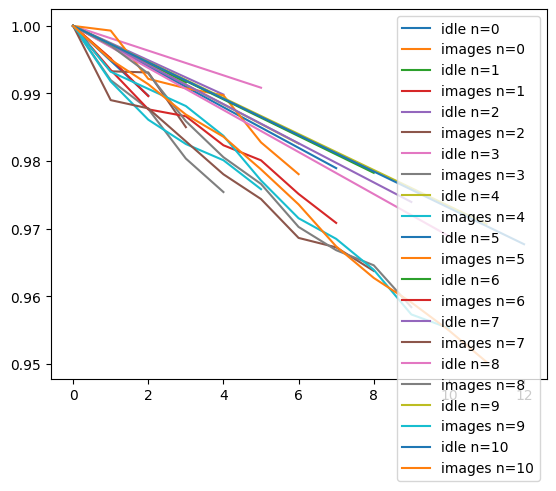

In [22]:
for n in range(n_max):
    plot_n(n)
plt.legend()
plt.show()

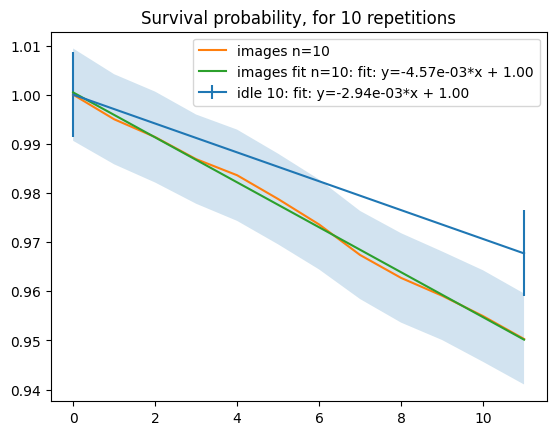

In [63]:
def calc_n(n):
    data_idle_n = data_idle[data_idle["n"] == n]
    mean_idle = data_idle_n.groupby("image_index")["total_atoms"].mean()
    std_idle = data_idle_n.groupby("image_index")["total_atoms"].std() / np.sqrt(n_reps)
    std_idle /= mean_idle.iloc[0]
    mean_idle /= mean_idle.iloc[0]

    data_images_n = data_images[data_images["n"] == n]
    mean_images = data_images_n.groupby("image_index")["total_atoms"].mean()
    std_images = data_images_n.groupby("image_index")["total_atoms"].std() / np.sqrt(n_reps)
    std_images /= mean_images.iloc[0]
    mean_images /= mean_images.iloc[0]

    # linear fit
    fit_idle = np.polyfit([0, len(mean_images)-1], mean_idle, 1)
    fit_images = np.polyfit(list(range(len(mean_images))), mean_images, 1)

    # plt.plot([0, len(mean_images)], mean_idle / mean_idle.iloc[0], label=f"idle n={n}")
    plt.errorbar([0, len(mean_images)-1], mean_idle, std_idle, label=f"idle {n}: fit: y={fit_idle[0]:.2e}*x + {fit_idle[1]:.2f}")
    plt.plot(mean_images, label=f"images n={n}")
    plt.plot(np.polyval(fit_images, list(range(len(mean_images)))), label=f"images fit n={n}: fit: y={fit_images[0]:.2e}*x + {fit_images[1]:.2f}")
    plt.fill_between(list(range(len(mean_images))), mean_images - std_images, mean_images + std_images, alpha=0.2)



    # return mean_idle, std_idle, mean_images, std_images``

calc_n(10)
plt.title("Survival probability, for 10 repetitions")
plt.legend()
plt.show()



In [ ]:
images_folder_path = r"Z:\victor\dynamic_imaging\Apr17_2026_154933images"
n_reps = 100
n_max = 11
numbering = DynamicImageNumbering(n_max=n_max, n_reps=n_reps)
analyzer_images = ImageAnalyzer(calibration_file="calibration20260309.json",
images_folder_path=images_folder_path,
numbering=numbering
)

# analyzer_images.analyze_images()
# data_images = analyzer_images.data
# atoms = pd.DataFrame(
#     data_images["atoms_in_image"].tolist(),
#     index=data_images.index,
#     columns=[f"atom_{i}" for i in range(100)],
# )
# data_images = pd.concat([data_images, atoms], axis=1)
# data_images.drop(columns=["atoms_in_image"]).to_parquet("images_data.parquet")
data_images = pd.read_parquet("images_data.parquet")

images analyzed with data taken on:  2026-03-09
expecting an atom array of size:  10 x 10
the ROIs are of size:  5 x 5
images to analyze are in:  Z:\victor\dynamic_imaging\Apr17_2026_154933images


In [63]:
data_images = analyzer_images.data
for i in range(100):
    data_images[f"atom_{i}"] = data_images["atoms_in_image"].apply(lambda x: x[i])

C:\Users\4G_QPU_Room\AppData\Local\Temp\ipykernel_15876\852372727.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_images[f"atom_{i}"] = data_images["atoms_in_image"].apply(lambda x: x[i])


In [73]:
def collect_bitstrings(n):
    bitstrings = {}
    data_images_n = data_images[data_images["n"] == n]
    with tqdm(total=n_reps * 100 * (n+2)) as pbar:
        for i_rep in range(n_reps):
            data_images_n_rep = data_images_n[data_images_n["repetition_index"] == i_rep]
            for i_atom in range(100):
                bitstring = ""
                for i_image in range(n+2):
                    data_images_n_rep_image = data_images_n_rep[data_images_n_rep["image_index"] == i_image]
                    bitstring += str(data_images_n_rep_image[f"atom_{i_atom}"].iloc[0])
                    pbar.update(1)
                bitstrings[bitstring] = bitstrings.get(bitstring, 0) + 1
    return bitstrings

collect_bitstrings(4)


100%|██████████| 60000/60000 [01:06<00:00, 902.56it/s] 


{'000000': 4124,
 '111111': 5456,
 '110110': 2,
 '111000': 21,
 '110111': 51,
 '011111': 33,
 '011110': 2,
 '110000': 29,
 '111110': 69,
 '111101': 43,
 '111100': 21,
 '100000': 30,
 '101111': 45,
 '111011': 49,
 '101101': 1,
 '011000': 1,
 '101000': 1,
 '001111': 2,
 '111001': 3,
 '101011': 4,
 '111010': 1,
 '110101': 3,
 '110011': 2,
 '101110': 2,
 '011100': 1,
 '010000': 1,
 '100101': 1,
 '100111': 2}

In [7]:
from collections import Counter

def collect_bitstrings(n, data):
    atom_cols = [f"atom_{i}" for i in range(100)]
    data_n = data.loc[data["n"] == n, ["repetition_index", "image_index", *atom_cols]]
    counts = Counter()
    for i_rep in range(n_reps):
        sub = data_n.loc[data_n["repetition_index"] == i_rep]
        # One numpy read per repetition; sort once so image order matches 0..n+1
        arr = sub.sort_values("image_index")[atom_cols].to_numpy(dtype=str, copy=False)
        # arr shape: (n + 2, 100) — one character/string per cell after astype(str)
        for i_atom in range(100):
            counts["".join(arr[:, i_atom])] += 1
    return dict(counts)

In [56]:
bitstrings = collect_bitstrings(10, data_images)
count = np.sum(list(bitstrings.values()))
threshold = 0.001
bitstrings = {k: v / count for k, v in sorted(bitstrings.items(), key=lambda x: x[1], reverse=True) if v > threshold * count}
bitstrings

{'111111111111': np.float64(0.51),
 '000000000000': np.float64(0.4157),
 '111111111110': np.float64(0.0056),
 '110111111111': np.float64(0.004),
 '111111110000': np.float64(0.0038),
 '111111101111': np.float64(0.0037),
 '011111111111': np.float64(0.0037),
 '101111111111': np.float64(0.0033),
 '111111111011': np.float64(0.0032),
 '111110000000': np.float64(0.003),
 '111101111111': np.float64(0.003),
 '111011111111': np.float64(0.003),
 '100000000000': np.float64(0.0028),
 '111111110111': np.float64(0.0028),
 '111111000000': np.float64(0.0028),
 '111111111101': np.float64(0.0028),
 '111000000000': np.float64(0.0027),
 '111110111111': np.float64(0.0026),
 '111111011111': np.float64(0.0026),
 '111111100000': np.float64(0.0024),
 '111111111100': np.float64(0.0021),
 '111100000000': np.float64(0.0021),
 '110000000000': np.float64(0.0021),
 '111111111000': np.float64(0.0019)}

In [48]:
def longest_run_start_ones(s: str) -> tuple[int, int]:
    """Longest run of '1'; on length ties, keep the lowest (leftmost) start."""
    best_len = 0
    best_start = 0
    i = 0
    n = len(s)
    while i < n:
        if s[i] != "1":
            i += 1
            continue
        j = i
        while j < n and s[j] == "1":
            j += 1
        length = j - i
        if length > best_len:
            best_len = length
            best_start = i
        i = j
    return best_start, best_len
def longest_run_start_zeros(s: str) -> tuple[int, int]:
    """Longest run of '0'; on length ties, keep the highest (rightmost) start."""
    best_len = 0
    best_start = 0
    i = 0
    n = len(s)
    while i < n:
        if s[i] != "0":
            i += 1
            continue
        j = i
        while j < n and s[j] == "0":
            j += 1
        length = j - i
        if length > best_len or (length == best_len and i > best_start):
            best_len = length
            best_start = i
        i = j
    return best_start, best_len
def is_loss(s: str) -> bool:
    if any(c not in "01" for c in s):
        raise ValueError("expected characters '0' and '1' only")
    start1, len1 = longest_run_start_ones(s)
    start0, len0 = longest_run_start_zeros(s)
    if len1 < 2 or len0 < 2:
        return False
    return start1 < start0

In [49]:
loss_prob = 0.0
loss_bitmaps = {}
for bitstring, probability in bitstrings.items():
    if is_loss(bitstring):
        loss_prob += probability
        loss_bitmaps[bitstring] = probability
print(loss_prob)
loss_bitmaps

0.024699999999999993


{'111111110000': np.float64(0.0038),
 '111110000000': np.float64(0.003),
 '111111000000': np.float64(0.0028),
 '111000000000': np.float64(0.0027),
 '111111100000': np.float64(0.0024),
 '111111111100': np.float64(0.0021),
 '111100000000': np.float64(0.0021),
 '110000000000': np.float64(0.0021),
 '111111111000': np.float64(0.0019),
 '111111100111': np.float64(0.0002),
 '111110111100': np.float64(0.0002),
 '111110011101': np.float64(0.0001),
 '111111010000': np.float64(0.0001),
 '111101000000': np.float64(0.0001),
 '101111100111': np.float64(0.0001),
 '111110011111': np.float64(0.0001),
 '111111110011': np.float64(0.0001),
 '011111100000': np.float64(0.0001),
 '110111100000': np.float64(0.0001),
 '101111001111': np.float64(0.0001),
 '111011111100': np.float64(0.0001),
 '011110000000': np.float64(0.0001),
 '111111111001': np.float64(0.0001),
 '111100111101': np.float64(0.0001),
 '111010100000': np.float64(0.0001)}

In [55]:
bitstrings = collect_bitstrings(10, data_images)
count = np.sum(list(bitstrings.values()))
threshold = 0.001
bitstrings = {k: v / count for k, v in sorted(bitstrings.items(), key=lambda x: x[1], reverse=True) if v > threshold * count}

loss_prob = 0.0
for bitstring, probability in bitstrings.items():
    if bitstring.count("0") > 0:
        loss_prob += probability
loss_prob

np.float64(0.4817000000000001)

In [51]:
from __future__ import annotations

import json
import random
from datetime import datetime, timezone
from pathlib import Path
from typing import Literal

Order = Literal["prob_desc", "prob_asc", "keys", "random"]


def _utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def _load_labeled_bitstrings(path: Path) -> set[str]:
    done: set[str] = set()
    if not path.is_file():
        return done
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            done.add(row["bitstring"])
    return done


def _sort_items(items: list[tuple[str, float]], order: Order) -> list[tuple[str, float]]:
    if order == "prob_desc":
        return sorted(items, key=lambda kv: (-kv[1], kv[0]))
    if order == "prob_asc":
        return sorted(items, key=lambda kv: (kv[1], kv[0]))
    if order == "keys":
        return sorted(items, key=lambda kv: kv[0])
    if order == "random":
        out = items[:]
        random.shuffle(out)
        return out
    raise ValueError(f"unknown order: {order!r}")


def interactive_label_bitstrings(
    prob_by_bitstring: dict[str, float],
    *,
    out_path: str | Path = "bitstring_loss_labels.jsonl",
    order: Order = "prob_desc",
    skip_labeled: bool = True,
) -> None:
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    already = _load_labeled_bitstrings(out_path) if skip_labeled else set()
    items = [(b, float(p)) for b, p in prob_by_bitstring.items()]
    items = _sort_items(items, order)

    pending = [(b, p) for b, p in items if b not in already]
    total = len(pending)
    if total == 0:
        print("Nothing to label (empty dict or all keys already in the output file).")
        return

    for idx, (bitstring, prob) in enumerate(pending, start=1):
        print("\n" + "=" * 72)
        print(f"[{idx}/{total}] bitstring: {bitstring}")
        print(f"prob: {prob}")

        while True:
            ans = input("Loss? [y/n/s=skip/q=quit]: ").strip().lower()
            if ans in ("q", "quit"):
                print("Stopped early.")
                return
            if ans in ("s", "skip", ""):
                print("Skipped (not saved).")
                break
            if ans in ("y", "yes", "l", "loss", "1", "true"):
                is_loss = True
                break
            if ans in ("n", "no", "w", "win", "0", "false"):
                is_loss = False
                break
            print("Unrecognized answer. Use y/n/s/q.")

        if ans in ("s", "skip", ""):
            continue
        if ans in ("q", "quit"):
            return

        record = {
            "bitstring": bitstring,
            "prob": prob,
            "is_loss": is_loss,
            "ts_utc": _utc_now_iso(),
        }
        with out_path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
        print(f"Saved -> {out_path.resolve()}")

    print("\nDone: no remaining items (or empty dict).")


# prob_by_bitstring = {...}
interactive_label_bitstrings(collect_bitstrings(10, data_images), out_path="bitstring_loss_labels.jsonl")


[1/84] bitstring: 111111111111
prob: 5100.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[2/84] bitstring: 000000000000
prob: 4157.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[3/84] bitstring: 111111111110
prob: 56.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[4/84] bitstring: 110111111111
prob: 40.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[5/84] bitstring: 111111110000
prob: 38.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[6/84] bitstring: 011111111111
prob: 37.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[7/84] bitstring: 111111101111
prob: 37.0
Saved -> C:\Users\4G_QPU_Room\Documents\victor_image_analyser\bitstring_loss_labels.jsonl

[8/84] bitstring: 101111111111
prob: 33.0
Saved -> C:\Users\4G_Q

In [75]:
from __future__ import annotations

import json
from pathlib import Path


def load_bitstring_labels(path: str | Path = "bitstring_loss_labels.jsonl") -> list[dict]:
    path = Path(path)
    rows: list[dict] = []
    if not path.is_file():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def print_probs_from_labels(path: str | Path = "bitstring_loss_labels.jsonl") -> None:
    for row in load_bitstring_labels(path):
        print(row["bitstring"], row["prob"])


# Or as a dict bitstring -> prob (last row wins if duplicates)
def probs_by_bitstring(path: str | Path = "bitstring_loss_labels.jsonl") -> dict[str, float]:
    out: dict[str, float] = {}
    for row in load_bitstring_labels(path):
        out[row["bitstring"]] = float(row["prob"])
    return out

is_loss = {
    entry["bitstring"]: entry["is_loss"] for entry in load_bitstring_labels()
}
is_loss

{'111111111111': False,
 '000000000000': False,
 '111111111110': False,
 '110111111111': False,
 '111111110000': True,
 '011111111111': False,
 '111111101111': False,
 '101111111111': False,
 '111111111011': False,
 '111011111111': False,
 '111101111111': False,
 '111110000000': True,
 '100000000000': True,
 '111111000000': True,
 '111111110111': False,
 '111111111101': False,
 '111000000000': True,
 '111110111111': False,
 '111111011111': False,
 '111111100000': True,
 '110000000000': True,
 '111100000000': True,
 '111111111100': True,
 '111111111000': True,
 '111111011101': False,
 '101111011111': False,
 '101111111101': False,
 '111001111111': False,
 '111110101111': False,
 '111111101110': False,
 '010000000000': False,
 '101111110111': False,
 '111011110111': False,
 '111011111011': False,
 '111101111110': False,
 '111110111100': False,
 '111110111101': False,
 '111110111110': False,
 '111111100111': False,
 '111111111010': False,
 '000001110000': False,
 '000001111111': False,
 '

In [78]:
bitstrings_prob = collect_bitstrings(10, data_images)
losses = 0
for k, v in bitstrings_prob.items():
    if is_loss[k]:
        losses += v
10 * losses / np.sum(list(bitstrings_prob.values()))

np.float64(0.263)